In [2]:
import torch
from matplotlib import pyplot as plt

X: Matrix N rows (samples) by n columns (features)
Xc: elementwise X - Xmean
W: Weight matrix 

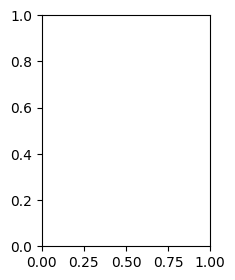

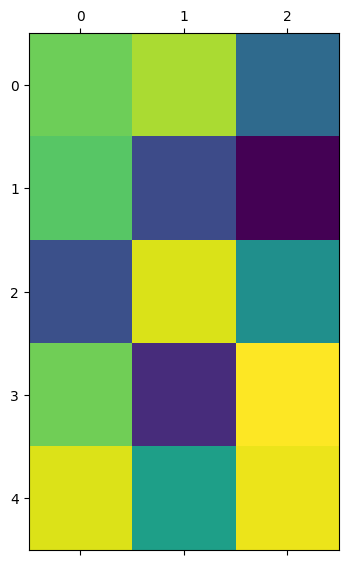

0 tensor(0.2628, grad_fn=<MseLossBackward0>)
10 tensor(0.1213, grad_fn=<MseLossBackward0>)
20 tensor(0.0596, grad_fn=<MseLossBackward0>)
30 tensor(0.0364, grad_fn=<MseLossBackward0>)
40 tensor(0.0273, grad_fn=<MseLossBackward0>)
50 tensor(0.0232, grad_fn=<MseLossBackward0>)
60 tensor(0.0211, grad_fn=<MseLossBackward0>)
70 tensor(0.0200, grad_fn=<MseLossBackward0>)
80 tensor(0.0194, grad_fn=<MseLossBackward0>)
90 tensor(0.0192, grad_fn=<MseLossBackward0>)


In [75]:
import torch.nn.functional as F
N = 10
n = 5
k = 3

X = torch.rand((N, n))
Xc = X - X.mean(0, keepdim=True)
W = torch.rand(n, k, requires_grad=True)
plt.figure(figsize=(10,3))
plt.subplot(1,4,1)
plt.matshow(W.detach())
plt.show()

epochs = 100
optimizer = torch.optim.Adam([W], lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

for i in range(epochs):
  XcW = Xc @ W # (N, n) @ (n, k) = (N, k)
  XcWWT = XcW @ W.T # (N, k) @ (k, n) = (N, n)
  loss = F.mse_loss(XcWWT, Xc)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  scheduler.step()

  if i % (epochs // 10) == 0 : print(i, loss)
  



In [30]:
N = 10
n = 5
k = 3

X = torch.rand((N, n))
Xc = X - X.mean()
xcc = X - X.mean(0, keepdim=True)
xu = X.mean() 
xuu = X.mean(0, keepdim=True)


print(xu)
print(xuu)
print()


print(xcc.sum())
print(Xc.sum())


tensor(0.4643)
tensor([[0.3785, 0.3336, 0.5442, 0.5462, 0.5188]])

tensor(-8.9407e-07)
tensor(-2.8610e-06)
